# MLOps Showcase — Exploração dos dados
Dataset: Numenta Anomaly Benchmark (NAB) — AWS CloudWatch

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_theme(style='whitegrid')
print('Libs carregadas!')

Libs carregadas!


In [2]:
DATA_PATH = '../data/raw/realAWSCloudwatch/realAWSCloudwatch/'
arquivos = glob.glob(DATA_PATH + '*.csv')
print(f'Total de arquivos: {len(arquivos)}')
for f in arquivos:
    print(' -', os.path.basename(f))

Total de arquivos: 17
 - ec2_cpu_utilization_5f5533.csv
 - rds_cpu_utilization_e47b3b.csv
 - ec2_disk_write_bytes_1ef3de.csv
 - iio_us-east-1_i-a2eb1cd9_NetworkIn.csv
 - ec2_cpu_utilization_c6585a.csv
 - elb_request_count_8c0756.csv
 - ec2_network_in_5abac7.csv
 - ec2_disk_write_bytes_c0d644.csv
 - ec2_cpu_utilization_77c1ca.csv
 - ec2_cpu_utilization_fe7f93.csv
 - ec2_cpu_utilization_825cc2.csv
 - ec2_cpu_utilization_53ea38.csv
 - ec2_cpu_utilization_ac20cd.csv
 - rds_cpu_utilization_cc0c53.csv
 - ec2_network_in_257a54.csv
 - grok_asg_anomaly.csv
 - ec2_cpu_utilization_24ae8d.csv


In [3]:
df = pd.read_csv(DATA_PATH + 'ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
print(df.shape)
df.head(10)

(4032, 1)


,value
timestamp,
2014-02-14 14:30:00,0.132
2014-02-14 14:35:00,0.134
2014-02-14 14:40:00,0.134
2014-02-14 14:45:00,0.134
2014-02-14 14:50:00,0.134
2014-02-14 14:55:00,0.134
2014-02-14 15:00:00,0.134
2014-02-14 15:05:00,0.134
2014-02-14 15:10:00,0.066


In [4]:
print(df.describe())
print(f'\nPeríodo: {df.index.min()} até {df.index.max()}')
print(f'Nulos: {df.isnull().sum().sum()}')

             value
count  4032.000000
mean      0.126303
std       0.094813
min       0.066000
25%       0.132000
50%       0.134000
75%       0.134000
max       2.344000

Período: 2014-02-14 14:30:00 até 2014-02-28 14:25:00
Nulos: 0


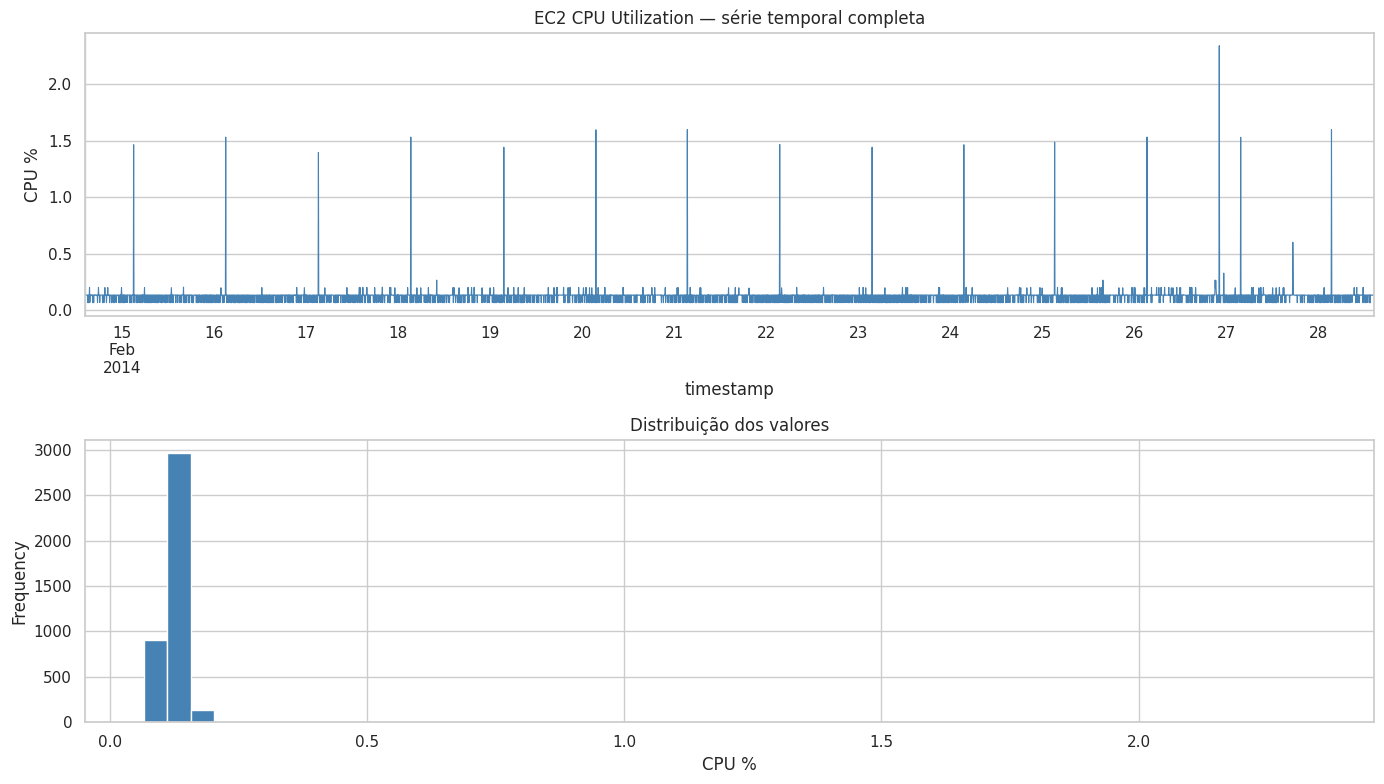

Gráfico salvo!


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df['value'].plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('EC2 CPU Utilization — série temporal completa')
axes[0].set_ylabel('CPU %')

df['value'].plot(kind='hist', ax=axes[1], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuição dos valores')
axes[1].set_xlabel('CPU %')

plt.tight_layout()
plt.savefig('../data/processed/eda_cpu_utilization.png', dpi=150)
plt.show()
print('Gráfico salvo!')

In [7]:
todos = []
for f in arquivos:
    tmp = pd.read_csv(f, parse_dates=['timestamp'])
    tmp['arquivo'] = os.path.basename(f)
    todos.append(tmp)

df_all = pd.concat(todos, ignore_index=True)
print(f'Total de registros: {len(df_all)}')
df_all.groupby('arquivo')['value'].describe()

Total de registros: 67740


,count,mean,std,min,25%,50%,75%,max
arquivo,,,,,,,,
ec2_cpu_utilization_24ae8d.csv,4032.0,1.263031e-01,9.481285e-02,0.0660,1.320000e-01,1.340000e-01,1.340000e-01,2.344000e+00
ec2_cpu_utilization_53ea38.csv,4032.0,1.829555e+00,1.014579e-01,1.6040,1.766000e+00,1.800000e+00,1.866000e+00,2.656000e+00
ec2_cpu_utilization_5f5533.csv,4032.0,4.311037e+01,4.303565e+00,34.7660,3.929600e+01,4.291800e+01,4.600600e+01,6.809200e+01
ec2_cpu_utilization_77c1ca.csv,4032.0,1.051818e+01,2.692863e+01,0.0640,9.800000e-02,1.000000e-01,1.020000e-01,9.989800e+01
ec2_cpu_utilization_825cc2.csv,4032.0,8.979126e+01,1.207871e+01,18.7225,8.908100e+01,9.244900e+01,9.429950e+01,9.911800e+01
ec2_cpu_utilization_ac20cd.csv,4032.0,4.098509e+01,2.192116e+01,2.4640,3.314600e+01,3.466200e+01,3.763300e+01,9.974200e+01
ec2_cpu_utilization_c6585a.csv,4032.0,8.694841e-02,8.521157e-02,0.0620,6.600000e-02,6.600000e-02,6.800000e-02,1.602000e+00
ec2_cpu_utilization_fe7f93.csv,4032.0,5.778964e+00,1.181169e+01,1.8000,2.178000e+00,2.582000e+00,3.425500e+00,9.966800e+01
ec2_disk_write_bytes_1ef3de.csv,4730.0,6.581561e+06,4.038568e+07,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,5.474570e+08
